In [23]:
# Data manipulation
import pandas as pd
import numpy as np

# Model fitting
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# cross validation using statsmodel prepartion
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score

from sklearn.model_selection import cross_val_score, cross_validate, KFold
from coef_std_err import print_coef_std_err as cse

class StatsmodelsRegressor(BaseEstimator, RegressorMixin):

    def __init__(self, sm_class, sm_formula):
        self.sm_class = sm_class
        self.sm_formula = sm_formula
        self.model = None
        self.result = None

    def fit(self, X, y):

        data = X.copy()

        lhs = self.sm_formula.split('~')[0].strip()

        data[lhs] = y.values

        self.model = self.sm_class(self.sm_formula, data=data)

        self.result = self.model.fit()

        return self

    def predict(self, X):

        return self.result.predict(X)

def kfold_split(data, n_fold):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from statsmodel
    :param n_fold: <int> Number of fold in k-fold CV
    :return df: <pandas DataFrame>  combined estimated coefficient and standard error of model estimate
    """
    kfold = KFold(n_splits = n_fold, 
                  shuffle = True, 
                  random_state=123)
    fold_train = {}
    fold_test = {}

    for i, (train, test) in enumerate(kfold.split(data)):
        print(f"fold {i+1}, train data rows: {len(train)}, test data rows: {len(test)}")
        fold_train[i] = data.iloc[train].copy()
        fold_test[i] = data.iloc[test].copy()
        
    return (fold_train, fold_test)


diamonds = pd.read_csv('diamonds.csv', index_col=0)
diamonds = diamonds[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price']]

# 1. Penjelasan Data

## Deskripsi Dataset
Penelitian ini menggunakan dataset **Diamonds** yang berisi sekitar 54.000 data diamond beserta karakteristik fisik dan kualitasnya.
Dataset ini digunakan untuk menganalisis faktor-faktor yang memengaruhi harga diamond serta membangun model regresi untuk prediksi harga.

---

## Variabel

| Variabel | Deskripsi |
|---|---|
| price | Harga diamond dalam dolar Amerika |
| carat | Berat diamond |
| cut | Kualitas potongan diamond |
| color | Kualitas warna diamond |
| clarity | Tingkat kejernihan diamond |
| depth | Persentase kedalaman diamond |
| table | Lebar bagian atas diamond relatif terhadap titik terlebar |

---

## Validitas dan Reliabilitas Data
Dataset dianggap valid dan reliabel karena:
- memiliki jumlah observasi yang besar,
- variabel telah terstandarisasi,
- dan sering digunakan dalam penelitian statistik serta machine learning.

---

## Pemeriksaan Kualitas Data

### Missing Value


In [24]:
# Pemeriksaan missing value
print(diamonds.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
dtype: int64


Hasil menunjukkan bahwa tidak terdapat missing value pada dataset.

### Data Duplikat

In [25]:
#Pemeriksaan data duplikat
print(diamonds.duplicated().sum())

803



Terdapat beberapa data duplikat pada dataset. Namun, data tersebut tidak dihapus karena beberapa diamond dapat memiliki karakteristik yang identik, seperti:
- carat,
- cut,
- color,
- clarity,
- dan price.

Sehingga data duplikat tidak selalu menunjukkan kesalahan input data.

---

# 2. Eksplorasi Data

## Scatterplot

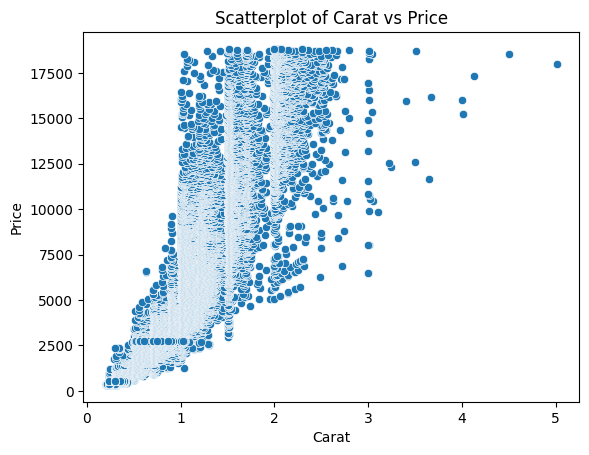

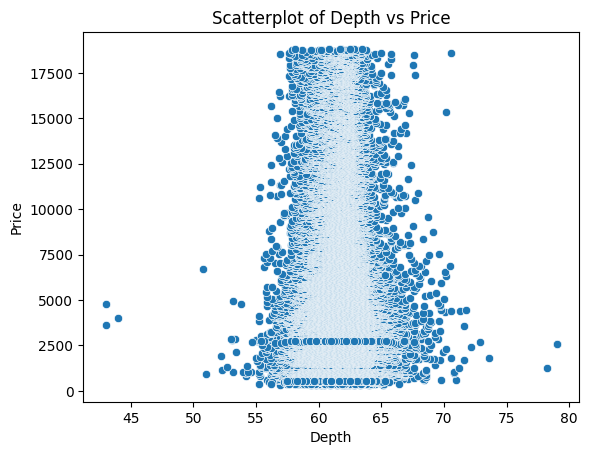

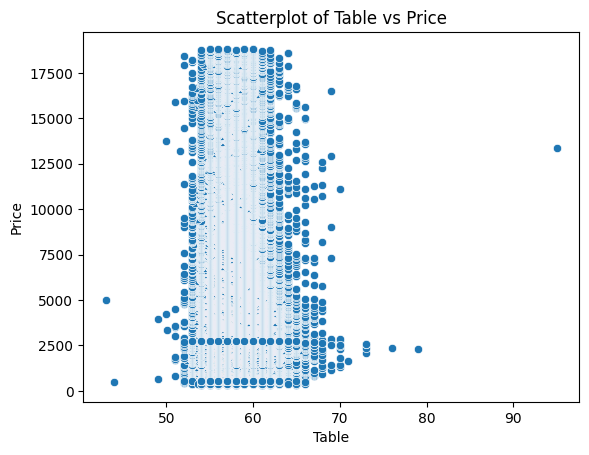

In [26]:
# Scatterplot digunakan untuk melihat hubungan antar variabel numerik terhadap harga diamond.
sns.scatterplot(data=diamonds, x='carat', y='price')
plt.title('Scatterplot of Carat vs Price')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()

sns.scatterplot(data=diamonds, x='depth', y='price')
plt.title('Scatterplot of Depth vs Price')
plt.xlabel('Depth')
plt.ylabel('Price')
plt.show()

sns.scatterplot(data=diamonds, x='table', y='price')
plt.title('Scatterplot of Table vs Price')
plt.xlabel('Table')
plt.ylabel('Price')
plt.show()

### Hasil Pengamatan Scatter Plot

#### 1. Carat vs Price
- Variabel `carat` menunjukkan hubungan positif yang sangat kuat dengan `price`.
- Semakin besar ukuran carat diamond, semakin tinggi harga diamond.
- Pola hubungan terlihat non-linear karena kenaikan harga menjadi semakin cepat pada nilai carat yang besar.


#### 2. Depth vs Price
- Variabel `depth` tidak menunjukkan hubungan yang kuat terhadap harga diamond.
- Harga diamond tersebar cukup luas pada setiap nilai depth, sehingga depth kemungkinan bukan prediktor utama harga diamond.


#### 3. Table vs Price
- Variabel `table` juga menunjukkan hubungan yang relatif lemah terhadap harga diamond.
- Tidak terlihat pola linear yang jelas antara table dan harga diamond.


### Kesimpulan
Berdasarkan scatter plot:
- `carat` merupakan variabel yang memiliki hubungan paling kuat terhadap `price`.
- `depth` dan `table` memiliki hubungan yang lebih lemah terhadap harga diamond.
- Distribusi harga diamond cenderung meningkat secara non-linear terhadap carat.

---

# 3. Uji Statistik

## Independent Sample t-test

### Tujuan
Mengetahui apakah terdapat perbedaan rata-rata harga diamond antara kategori cut Premium dan Ideal.

---

## Hipotesis

### H0

```math
\mu_{Premium} = \mu_{Ideal}
```

Tidak terdapat perbedaan rata-rata harga diamond antara kategori Premium dan Ideal.

### H1

```math
\mu_{Premium} \ne \mu_{Ideal}
```

Terdapat perbedaan rata-rata harga diamond antara kategori Premium dan Ideal.

---

## Tingkat Signifikansi

```math
\alpha = 0.05
```

---

t menolak H0
Tolak H0


t critic = 1.96
t = 24.92
p_value = 0.0


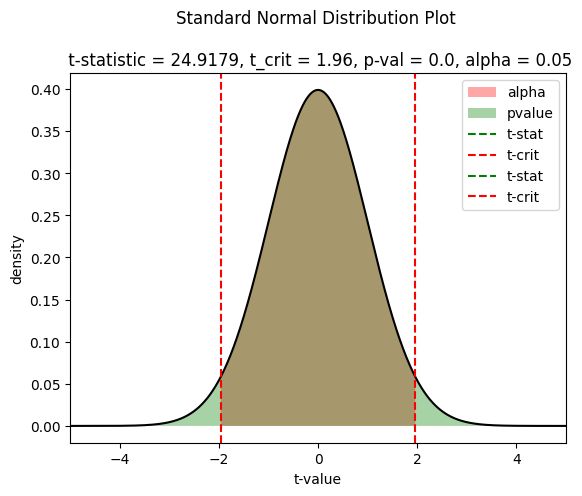

In [27]:
from scipy import stats

premium_filter = diamonds.loc[diamonds['cut'].isin(['Premium'])]
ideal_filter = diamonds.loc[diamonds['cut'].isin(['Ideal'])]

significant_level = 0.05

t_statistic, pvalue = stats.ttest_ind(a = premium_filter['price'], 
                         b = ideal_filter['price'], 
                         equal_var=False, 
                         alternative = 'two-sided')

t_crit = stats.t.ppf(1 - significant_level/2, df = len(premium_filter)+len(ideal_filter)-2)

if abs(t_statistic) > t_crit:
    print('t menolak H0')
else:
    print('t gagal menolak H0')

if pvalue < significant_level :
    print('Tolak H0')
else:
    print('Gagal menolak H0')

print('\n')

print(f't critic = {np.round(t_crit,2)}')

print(f't = {np.round(t_statistic,2)}')

print(f'p_value = {np.round(pvalue,5)}')

# Plot
x = np.arange(-5, 5, 0.001)
plt.plot(x, stats.norm.pdf(x, 0, 1), color = 'black')


# plot alpha region
x_alpha = np.arange(-t_crit, t_crit, 0.01)
y_alpha = stats.norm.pdf(x_alpha)
plt.fill_between(x = x_alpha, 
                 y1 = y_alpha,
                 facecolor = 'red',
                 alpha = 0.35, 
                 label = 'alpha')
# plot pvalue
x_pvalue = np.arange(-t_statistic, t_statistic, 0.01)
y_pvalue = stats.norm.pdf(x_pvalue)
plt.fill_between(x = x_pvalue, 
                 y1 = y_pvalue,
                 facecolor = 'green',
                 alpha = 0.35, 
                 label = 'pvalue')

# plot t-crit and t-stats
plt.axvline(t_statistic, 
            color ="green", 
            linestyle = "--", 
            label ="t-stat")
plt.axvline(t_crit, 
            color ="red", 
            linestyle = "--", 
            label ="t-crit")
plt.axvline(-t_statistic, 
            color ="green", 
            linestyle = "--", 
            label ="t-stat")
plt.axvline(-t_crit, 
            color ="red", 
            linestyle = "--", 
            label ="t-crit")

plt.legend()
plt.xlabel("t-value")
plt.ylabel("density")

plt.title(f'Standard Normal Distribution Plot \n\n t-statistic = {np.round(t_statistic, 4)}, t_crit = {np.round(t_crit, 4)}, p-val = {np.round(pvalue, 4)}, alpha = {significant_level}')
plt.xlim(-5, 5)
plt.show()



## Interpretasi Hasil
nilai p-value < 0.05 dan nilai absolut t-stat lebih besar dari t-critic, maka H0 ditolak

Hal ini menunjukkan bahwa terdapat perbedaan rata-rata harga yang signifikan antara diamond kategori Premium dan Ideal.

---

# 4. Analisis Model Regresi

## Model Regresi Sederhana 1 prediktor

### Outcome 
- `price`

### Predictor
- `carat`

## Persamaan Regresi

```math
\log(price) =
\beta_0 +
\beta_1(carat)
```

---

In [28]:
formula = 'price ~ carat'
model_simple = smf.ols(formula, data=diamonds).fit()

## Visualization
- Scatter plot `carat` vs `price`
- Fitted regression line

Text(0, 0.5, 'Price')

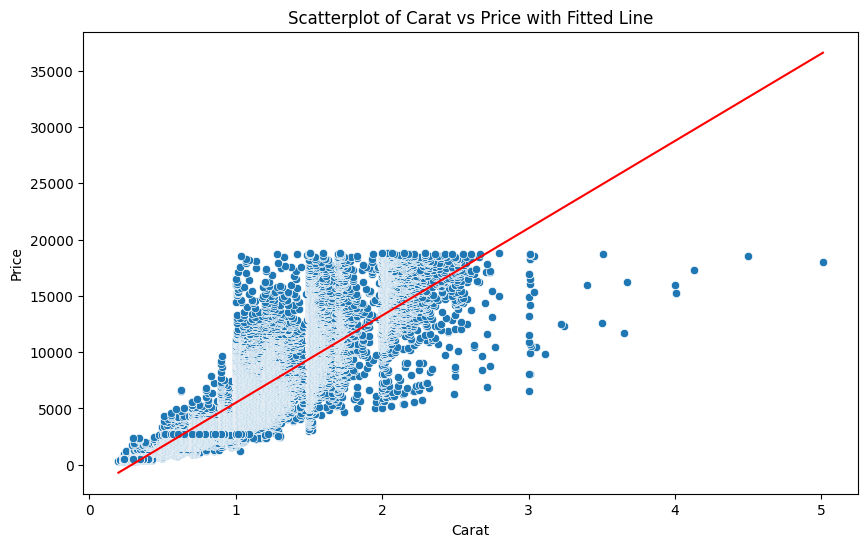

In [29]:
# 'price' vs 'carat' 
x_fit = np.linspace(diamonds['carat'].min(), diamonds['carat'].max(), 100)
y_fit = model_simple.predict(pd.DataFrame({'carat': x_fit}))

plt.figure(figsize=(10, 6))
sns.scatterplot(x='carat', y='price', data=diamonds)
plt.plot(x_fit, y_fit, color='red', label='Fitted Line')
plt.title('Scatterplot of Carat vs Price with Fitted Line')
plt.xlabel('Carat')
plt.ylabel('Price')

## Model Evaluation
Model di evaluasi dengan:
- R-squared value
- Residual plots
- Standard error of coefficients
- Cross Validation

In [30]:
simple_regression = smf.ols('price ~ carat', data=diamonds).fit()
print(simple_regression.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:31   Log-Likelihood:            -4.7273e+05
No. Observations:               53940   AIC:                         9.455e+05
Df Residuals:                   53938   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2256.3606     13.055   -172.830      0.0

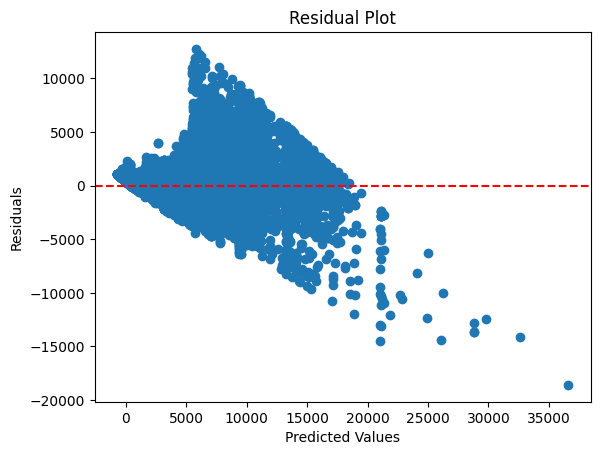

In [31]:
# residual plot
y_pred = simple_regression.predict(diamonds[['carat']])

residual = simple_regression.resid

plt.scatter(x = y_pred, y = residual)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [32]:
# K-fold cross validation
print(f'adjusted R-squared: {simple_regression.rsquared_adj:.4f}')
print(f'R-squared: {simple_regression.rsquared:.4f}\n')

kfold = KFold(n_splits=5, shuffle = True, random_state=123)
retail_score = cross_val_score(estimator = StatsmodelsRegressor(sm_class=smf.ols, sm_formula='price ~ carat'),
                               X = diamonds[['carat']],
                               y = diamonds[['price']], 
                               cv = kfold, 
                               scoring = 'r2')
retail_score = pd.DataFrame(data = retail_score, columns=["test_rsquared"])
retail_score["folds"] = [f"Folds {i+1}" for i in range(5)]

print(retail_score)

print(f"Mean R-squared: {retail_score['test_rsquared'].mean():.4f}")

adjusted R-squared: 0.8493
R-squared: 0.8493

   test_rsquared    folds
0       0.848968  Folds 1
1       0.848547  Folds 2
2       0.855093  Folds 3
3       0.846664  Folds 4
4       0.847058  Folds 5
Mean R-squared: 0.8493


The model simple reression will be evaluated using:
- R-squared value -> 0.849 -> good
- Residual plots -> ada pola melengkung (non-linear) serta adanya Corong/Kipas (Heteroskedastisitas) perlu di transformasi
- Standard error of coefficients -> prediktor carat memiliki nilai t statistik di sekitar 500 -> sangat bagus
- cross validation -> stabil (ditandai r-square dan mean r-square hasil 5-fold sama)

---

## Model Regresi Multiprediktor

## Variables

### Outcome
- `price`

### Predictors
- `carat`
- `cut`
- `color`
- `clarity`
- `depth`
- `table`


## Regression Model

```math
price = \beta_0 + \beta_1(carat) + \beta_2(cut) + \beta_3(color) + \beta_4(clarity) + \beta_5(depth) + \beta_6(table)
```

In [33]:
multiple_regression = smf.ols('price ~ carat + depth + table + C(cut) + C(color) + C(clarity)', data=diamonds).fit()

## Model Evaluation
Model di evaluasi dengan:
- R-squared value
- Residual plots
- Standard error of coefficients
- Cross Validation

In [34]:
multiple_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 2.942e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:32   Log-Likelihood:            -4.5696e+05
No. Observations:               53940   AIC:                         9.140e+05
Df Residuals:                   53919   BIC:                         9.141e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -4555.1714    373.482    -12.197      0.000   -5287.199   -3823.144
C(cut)[T.Good]        614.4239     34.337     17.894      0.000     547.122     681.726
C(cut)[T.Ideal]       877.5691     34.152     25.696      0.000     810.631     944.507
C(cut)[T.Premium]     806.0243     32.954     24.459      0.000     741.434     870.615
C(cut)[T.Very Good]   778.4282     32.936     23.635      0.000     713.874     842.982
C(color)[T.E]        -210.8490     18.304    -11.519      0.000    -246.726    -174.972
C(color)[T.F]        -304.2876     18.498    -16.450      0.000    -340.543    -268.032
C(color)[T.G]        -506.9637     18.116    -27.984      0.000    -542.472    -471.456
C(color)[T.H]        -977.9737     19.269    -50.754      0.000   -1015.741    -940.207
C(color)[T.I]       -1438.2773     21.642    -66.459      0.000   -1480.695   -1395.860
C(color)[T.J]       -2322.5649     26.715    -86.940      0.000   -2374.926   -2270.204
C(clarity)[T.IF]     5404.2365     52.174    103.582      0.000    5301.976    5506.497
C(clarity)[T.SI1]    3567.7938     44.587     80.020      0.000    3480.404    3655.184
C(clarity)[T.SI2]    2619.0040     44.788     58.476      0.000    2531.220    2706.788
C(clarity)[T.VS1]    4525.4001     45.547     99.356      0.000    4436.127    4614.673
C(clarity)[T.VS2]    4210.1943     44.840     93.893      0.000    4122.307    4298.082
C(clarity)[T.VVS1]   5061.7344     48.224    104.964      0.000    4967.216    5156.253
C(clarity)[T.VVS2]   4957.3104     46.901    105.697      0.000    4865.384    5049.237
carat                8895.1940     12.079    736.390      0.000    8871.518    8918.870
depth                 -21.0236      4.079     -5.154      0.000     -29.019     -13.028
table                 -24.8027      2.978     -8.329      0.000     -30.639     -18.966
==============================================================================
Omnibus:                    15255.775   Durbin-Watson:                   0.908
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           184788.880
Skew:                           1.016   Prob(JB):                         0.00
Kurtosis:                      11.837   Cond. No.                     6.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

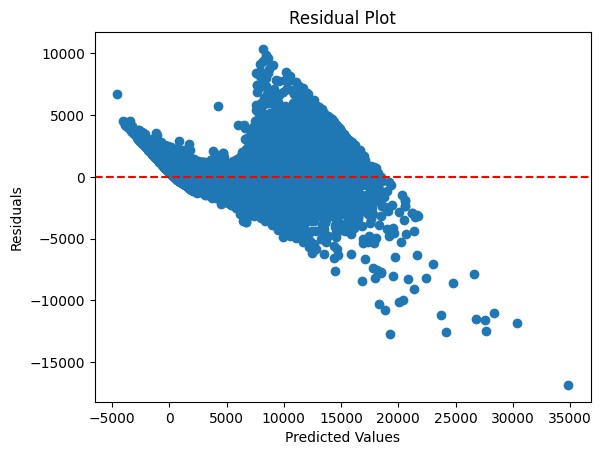

In [35]:
# residual plot
y_pred = multiple_regression.predict(diamonds[['carat', 'depth', 'table', 'cut', 'color', 'clarity']])

residual = multiple_regression.resid

plt.scatter(x = y_pred, y = residual)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [36]:
# K-fold cross validation
print(f'adjusted R-squared: {multiple_regression.rsquared_adj:.4f}')
print(f'R-squared: {multiple_regression.rsquared:.4f}\n')

kfold = KFold(n_splits=5, shuffle = True, random_state=123)
retail_score = cross_val_score(estimator = StatsmodelsRegressor(sm_class=smf.ols, sm_formula='price ~ carat + depth + table + C(cut) + C(color) + C(clarity)'),
                               X = diamonds[['carat', 'cut', 'color', 'clarity', 'depth', 'table']],
                               y = diamonds[['price']], 
                               cv = kfold, 
                               scoring = 'r2')
retail_score = pd.DataFrame(data = retail_score, columns=["test_rsquared"])
retail_score["folds"] = [f"Folds {i+1}" for i in range(5)]

print(retail_score)

print(f"Mean R-squared: {retail_score['test_rsquared'].mean():.4f}")

adjusted R-squared: 0.9160
R-squared: 0.9161

   test_rsquared    folds
0       0.915207  Folds 1
1       0.915856  Folds 2
2       0.919806  Folds 3
3       0.913285  Folds 4
4       0.915466  Folds 5
Mean R-squared: 0.9159


The model simple reression will be evaluated using:
- R-squared value -> 0.916 -> good
- Residual plots -> ada pola menurun serta adanya Corong/Kipas (Heteroskedastisitas) perlu di transformasi
- Standard error of coefficients -> prediktor carat, depth, table memiliki nilai absolut t statistik di atas 2 -> sangat bagus
- cross validation -> stabil (ditandai r-square dan mean r-square hasil 5-fold tidak jauh berbeda)

----

## Regression Model Multipredictor with Interaction

### Outcome
- `price`

### Predictors
- `carat`
- `cut`
- `color`
- `clarity`
- `depth`
- `table`
- interaction

## Interaction Term

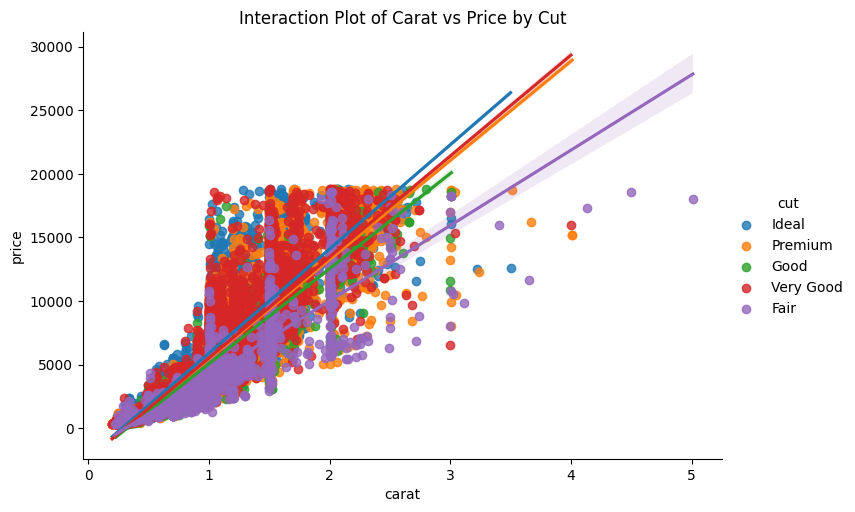

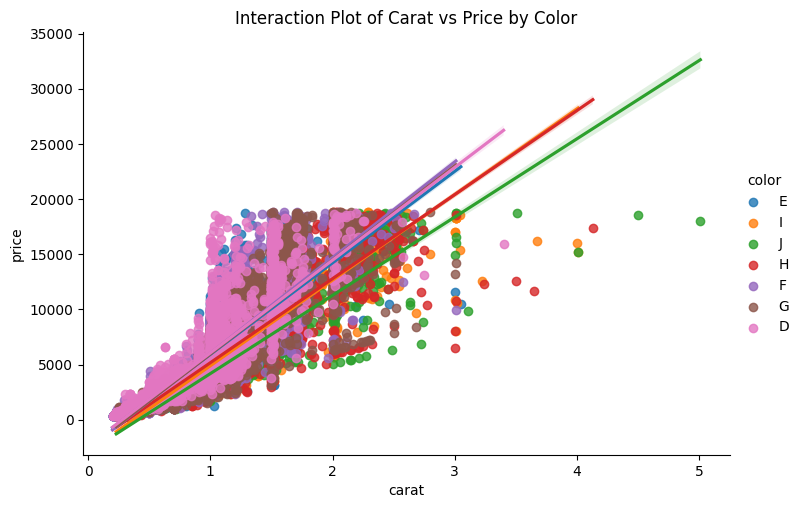

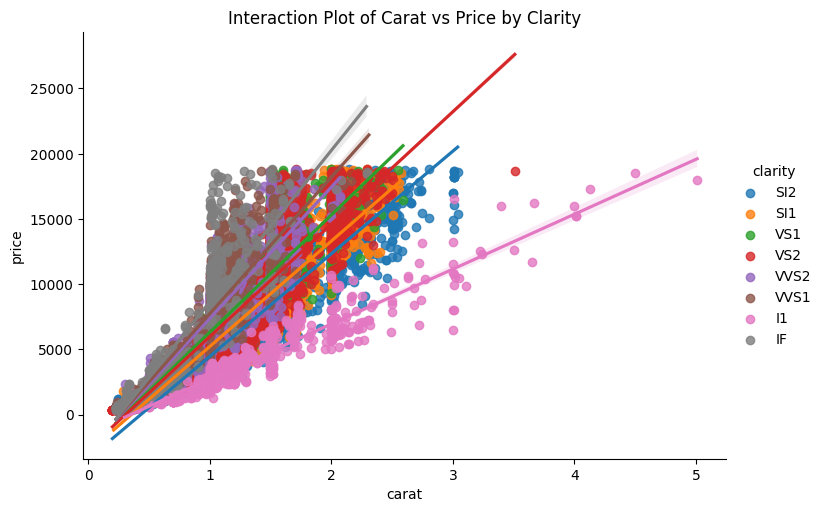

In [37]:
# Interaction graph
sns.lmplot(x='carat', y='price', hue='cut', data=diamonds, aspect=1.5)
plt.title('Interaction Plot of Carat vs Price by Cut')
sns.lmplot(x='carat', y='price', hue='color', data=diamonds, aspect=1.5)
plt.title('Interaction Plot of Carat vs Price by Color')
sns.lmplot(x='carat', y='price', hue='clarity', data=diamonds, aspect=1.5)
plt.title('Interaction Plot of Carat vs Price by Clarity')
plt.show()

Interaction term antara `carat` dan `clarity` dipilih karena pada `scatter plot` terlihat bahwa setiap kategori clarity memiliki slope hubungan `carat` terhadap `price` yang berbeda dan relatif paling berjauhan dibanding kategori lainnya.

Hal ini mengindikasikan adanya interaksi antara `carat` dan `clarity` terhadap harga diamond.

## Persamaan Regresi
```math
price = \beta_0 + \beta_1(carat) + \beta_2(cut) + \beta_3(color) + \beta_4(clarity) + \beta_5(depth) + \beta_6(table) + \beta_7(carat \times clarity)
```

In [38]:
interaction_model = smf.ols('price ~ carat + C(cut) + C(color) + C(clarity) + depth + table + carat:C(clarity)', data=diamonds).fit()

## Model Evaluation
Model di evaluasi dengan:
- R-squared value
- Residual plots
- Standard error of coefficients
- Cross Validation

In [39]:
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.631e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:45   Log-Likelihood:            -4.5226e+05
No. Observations:               53940   AIC:                         9.046e+05
Df Residuals:                   53912   BIC:                         9.048e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

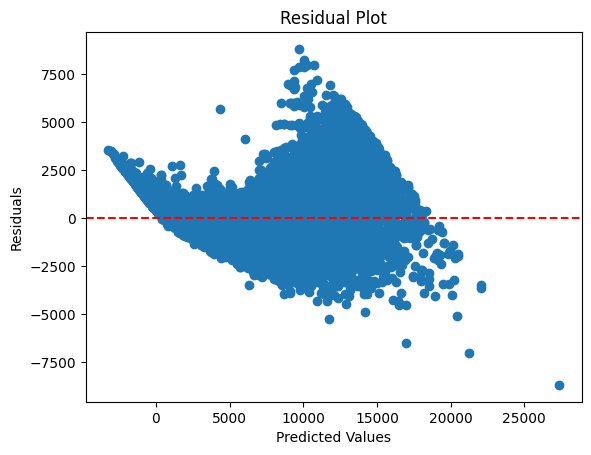

In [40]:
# residual plot
y_pred = interaction_model.predict(diamonds[['carat', 'depth', 'table', 'cut', 'color', 'clarity']])

residual = interaction_model.resid

plt.scatter(x = y_pred, y = residual)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [41]:
# K-fold cross validation
print(f'adjusted R-squared: {interaction_model.rsquared_adj:.4f}')
print(f'R-squared: {interaction_model.rsquared:.4f}\n')

kfold = KFold(n_splits=5, shuffle = True, random_state=123)
retail_score = cross_val_score(estimator = StatsmodelsRegressor(sm_class=smf.ols, sm_formula='price ~ carat + depth + table + C(cut) + C(color) + C(clarity) + carat:C(clarity)'),
                               X = diamonds[['carat', 'cut', 'color', 'clarity', 'depth', 'table']],
                               y = diamonds[['price']], 
                               cv = kfold, 
                               scoring = 'r2')
retail_score = pd.DataFrame(data = retail_score, columns=["test_rsquared"])
retail_score["folds"] = [f"Folds {i+1}" for i in range(5)]

print(retail_score)

print(f"Mean R-squared: {retail_score['test_rsquared'].mean():.4f}")

adjusted R-squared: 0.9294
R-squared: 0.9295

   test_rsquared    folds
0       0.929828  Folds 1
1       0.929308  Folds 2
2       0.932790  Folds 3
3       0.925985  Folds 4
4       0.928363  Folds 5
Mean R-squared: 0.9293


The model simple reression will be evaluated using:
- R-squared value -> 0.929 -> good
- Residual plots -> ada pola melengkung (non linear) serta adanya Corong/Kipas (Heteroskedastisitas) perlu di transformasi
- Standard error of coefficients -> prediktor carat, depth, table memiliki nilai absolut t statistik di atas 2 -> sangat bagus
- cross validation -> stabil (ditandai r-square dan mean r-square hasil 5-fold tidak jauh berbeda)

----

## Model Regresi Final

Model regresi final menggunakan:
- multiple regression,
- transformasi logaritma,
- dan interaction term antara `log_carat` dan `clarity`.

## Persamaan Regresi

```math
\log(price) =
\beta_0 +
\beta_1(log\_carat) +
\beta_2(depth) +
\beta_3(log\_table) +
\beta_4(cut) +
\beta_5(color) +
\beta_6(clarity) +
\beta_7(log\_carat \times clarity) +
\epsilon
```


In [42]:
diamonds_copy = diamonds.copy()
diamonds_copy['log_price'] = np.log(diamonds_copy['price'])
diamonds_copy['log_carat'] = np.log(diamonds_copy['carat'])
diamonds_copy['log_table'] = np.log(diamonds_copy['table'])

formula_log = 'log_price ~ log_carat + C(cut) + C(color) + C(clarity) + depth + log_table + C(clarity):log_carat'
model_log = smf.ols(formula_log, data=diamonds_copy).fit()
model_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.144e+05
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:48   Log-Likelihood:                 32330.
No. Observations:               53940   AIC:                        -6.460e+04
Df Residuals:                   53912   BIC:                        -6.436e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        8.0399      0.098     82.347      0.000       7.849       8.231
C(cut)[T.Good]                   0.0780      0.004     19.768      0.000       0.070       0.086
C(cut)[T.Ideal]                  0.1576      0.004     40.241      0.000       0.150       0.165
C(cut)[T.Premium]                0.1364      0.004     36.048      0.000       0.129       0.144
C(cut)[T.Very Good]              0.1147      0.004     30.330      0.000       0.107       0.122
C(color)[T.E]                   -0.0548      0.002    -25.987      0.000      -0.059      -0.051
C(color)[T.F]                   -0.0957      0.002    -44.920      0.000      -0.100      -0.092
C(color)[T.G]                   -0.1607      0.002    -77.028      0.000      -0.165      -0.157
C(color)[T.H]                   -0.2511      0.002   -113.062      0.000      -0.255      -0.247
C(color)[T.I]                   -0.3728      0.002   -150.021      0.000      -0.378      -0.368
C(color)[T.J]                   -0.5108      0.003   -166.917      0.000      -0.517      -0.505
C(clarity)[T.IF]                 1.0753      0.008    132.316      0.000       1.059       1.091
C(clarity)[T.SI1]                0.5606      0.005    104.699      0.000       0.550       0.571
C(clarity)[T.SI2]                0.3899      0.005     72.717      0.000       0.379       0.400
C(clarity)[T.VS1]                0.7778      0.006    140.306      0.000       0.767       0.789
C(clarity)[T.VS2]                0.7004      0.005    129.540      0.000       0.690       0.711
C(clarity)[T.VVS1]               0.9676      0.007    142.092      0.000       0.954       0.981
C(clarity)[T.VVS2]               0.9142      0.006    152.312      0.000       0.902       0.926
log_carat                        1.6214      0.011    153.086      0.000       1.601       1.642
C(clarity)[T.IF]:log_carat       0.2619      0.012     21.007      0.000       0.237       0.286
C(clarity)[T.SI1]:log_carat      0.2805      0.011     25.962      0.000       0.259       0.302
C(clarity)[T.SI2]:log_carat      0.2597      0.011     23.754      0.000       0.238       0.281
C(clarity)[T.VS1]:log_carat      0.2696      0.011     24.722      0.000       0.248       0.291
C(clarity)[T.VS2]:log_carat      0.2532      0.011     23.460      0.000       0.232       0.274
C(clarity)[T.VVS1]:log_carat     0.2461      0.012     21.294      0.000       0.223       0.269
C(clarity)[T.VVS2]:log_carat     0.2695      0.011     24.199      0.000       0.248       0.291
depth                           -0.0008      0.000     -1.611      0.107      -0.002       0.000
log_table                       -0.0235      0.020     -1.179      0.238      -0.063       0.016
============================================================================

## Analisis Residual

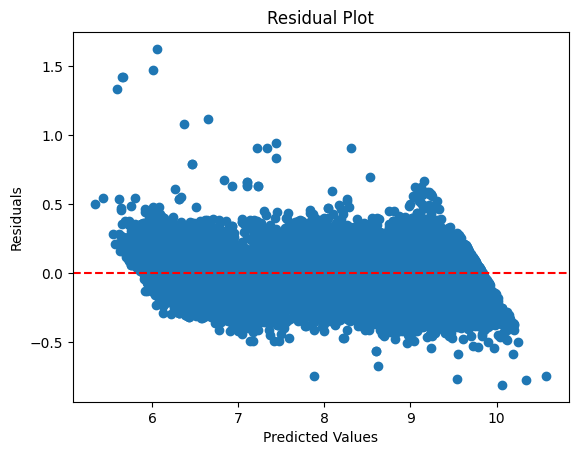

In [43]:
# Residual plot digunakan untuk mengevaluasi asumsi regresi.
y_pred = model_log.predict(diamonds_copy[['log_carat', 'cut', 'color', 'clarity', 'depth', 'log_table']])

residual = model_log.resid

plt.scatter(x = y_pred, y = residual)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Hasil
- Setelah transformasi logaritma, residual menjadi lebih stabil atau menyebar merata.
---

## Prediction Interval

Prediction interval pada rentang [0.025, 0.975] pada output summary digunakan untuk memperkirakan rentang kemungkinan harga diamond berdasarkan karakteristik tertentu.

Interval tersebut menunjukkan batas bawah dan batas atas prediksi harga diamond dengan tingkat kepercayaan 95%.

Prediction interval membantu mengukur ketidakpastian model dalam memprediksi harga diamond pada observasi baru.

---

## Cross Validation

Cross validation digunakan untuk mengevaluasi kemampuan generalisasi model terhadap variasi data yang berbeda.

Pada penelitian ini digunakan 5-Fold Cross Validation untuk menguji kestabilan model regresi.


In [44]:
# Cross validation K-Folds
print(f'adjusted R-squared: {model_log.rsquared_adj:.4f}')
print(f'R-squared: {model_log.rsquared:.4f}\n')

kfold = KFold(n_splits=5, shuffle = True, random_state=123)
retail_score = cross_val_score(estimator = StatsmodelsRegressor(sm_class=smf.ols, sm_formula=formula_log),
                               X = diamonds_copy[['log_carat', 'cut', 'color', 'clarity', 'depth', 'log_table']],
                               y = diamonds_copy[['log_price']], 
                               cv = kfold, 
                               scoring = 'r2')
retail_score = pd.DataFrame(data = retail_score, columns=["test_rsquared"])
retail_score["folds"] = [f"Folds {i+1}" for i in range(5)]

print(retail_score)

print(f"Mean R-squared: {retail_score['test_rsquared'].mean():.4f}")

adjusted R-squared: 0.9828
R-squared: 0.9828

   test_rsquared    folds
0       0.982646  Folds 1
1       0.983125  Folds 2
2       0.983114  Folds 3
3       0.982236  Folds 4
4       0.982977  Folds 5
Mean R-squared: 0.9828


# Kesimpulan

- `log_carat` merupakan prediktor paling kuat terhadap harga diamond.
- Kualitas cut, color, dan clarity berpengaruh signifikan terhadap harga diamond.
- Interaction antara `log_carat` dan `clarity` meningkatkan performa model karena pengaruh carat berbeda pada setiap tingkat clarity.
- Transformasi logaritma berhasil meningkatkan performa model dan memperbaiki asumsi regresi.
- Model akhir memiliki performa yang sangat baik dengan nilai Adjusted R-squared sebesar 0.983.
- Hasil uji CV menunjukkan hasil R-squared sangat baik sebesar 98%